# Epilepsy: 4-class clustering of motion-sensor recordings

UEA Epilepsy benchmark (Villar et al. 2016). 275 records of length 206, three-channel wrist accelerometer (x, y, z), four balanced classes: EPILEPSY (seizure motion), RUNNING, WALKING, SAWING.

Classes differ along two essentially independent amplitude axes: per-channel signal energy and per-channel peak-to-peak swing.

`filt_energy` is L2 in the 3-d per-channel `sqrt(sum_t x_t^2)` space.

`filt_ampch` is L2 in the 3-d per-channel `max_t x_t - min_t x_t` space.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                              f1_score, precision_score, recall_score)
from scipy.spatial.distance import cdist
from tslearn.datasets import UCR_UEA_datasets
import hdbscan

from mpc.filtration_builder import assemble_filtration
from mpc.pipeline import run_bifiltration_edges
from mpc.experiment_utils import align_hungarian

## Data

full set: N=275 L=206 C=3 classes=['EPILEPSY', 'RUNNING', 'SAWING', 'WALKING']
subsample: N=200 L=206 C=3, class counts: [50 50 50 50]


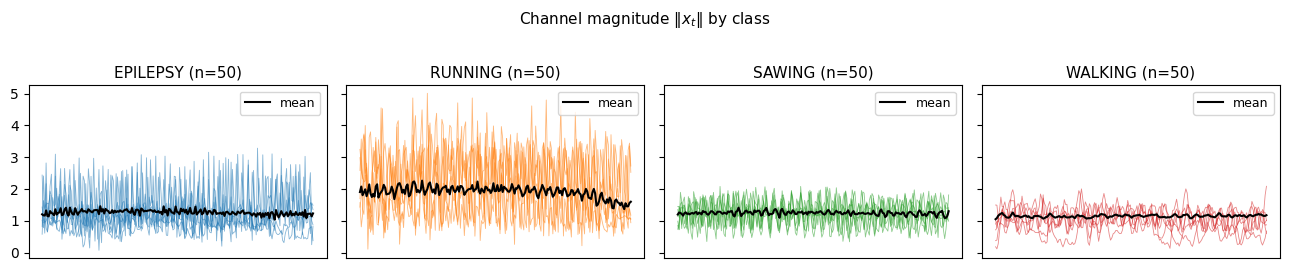

In [8]:
X_tr, y_tr, X_te, y_te = UCR_UEA_datasets().load_dataset('Epilepsy')
X_full = np.vstack([X_tr, X_te])
y_str = np.concatenate([y_tr, y_te])
CLASSES, y_full = np.unique(y_str, return_inverse=True)
print(f'full set: N={len(X_full)} L={X_full.shape[1]} C={X_full.shape[2]} classes={CLASSES.tolist()}')

K_TRUE = len(CLASSES)
PER_CLASS = 50
rng = np.random.default_rng(42)
sel = []
for c in range(K_TRUE):
    idx_c = np.where(y_full == c)[0]
    sel.extend(rng.choice(idx_c, PER_CLASS, replace=False))
sel = np.array(sel); rng.shuffle(sel)
X = X_full[sel]; y_true = y_full[sel]
N, L, C = X.shape
print(f'subsample: N={N} L={L} C={C}, class counts: {np.bincount(y_true)}')

CLASS_COLORS = ['C0', 'C1', 'C2', 'C3']
fig, axes = plt.subplots(1, K_TRUE, figsize=(13, 2.6), sharey=True)
for ax, c in zip(axes, range(K_TRUE)):
    mag_c = np.linalg.norm(X[y_true == c], axis=2)
    for m in mag_c[:6]:
        ax.plot(m, color=CLASS_COLORS[c], lw=0.6, alpha=0.55)
    ax.plot(mag_c.mean(0), color='k', lw=1.5, label='mean')
    ax.set_title(f'{CLASSES[c]} (n={(y_true == c).sum()})', fontsize=11)
    ax.set_xticks([])
    ax.legend(fontsize=9)
fig.suptitle('Channel magnitude $\\|x_t\\|$ by class', y=1.02, fontsize=11)
fig.tight_layout()
plt.show()

## Filtrations

Two amplitude axes on the full set of 200 records.

`filt_energy` -- L2 in the 3-d per-channel energy space, `sqrt(sum_t x_t^2)`.

`filt_ampch` -- L2 in the 3-d per-channel peak-to-peak space, `max_t x_t - min_t x_t`.

In [ ]:
Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-9)
energy_pc = np.sqrt((X ** 2).sum(axis=1))
ampch = X.max(axis=1) - X.min(axis=1)

D_energy = cdist(energy_pc, energy_pc)
D_ampch = cdist(ampch, ampch)

iu, ju = np.triu_indices(N, k=1)
edges = list(zip(iu.tolist(), ju.tolist()))
filt_energy = assemble_filtration(N, edges, D_energy[iu, ju])
filt_ampch  = assemble_filtration(N, edges, D_ampch[iu, ju])
print(f"N={N}, edges={len(edges)}")

N=200, edges=19900


## Clustering

Each method runs once on the full set. Metrics: ARI, NMI, and macro precision/recall/F1 after Hungarian alignment to ground-truth labels.

Bifiltration on `filt_energy x filt_ampch`, simplify mode, `slope = 1`, `K = 4`, `min_size = N / 10`.

KMeans, Ward, HDBSCAN run on the z-normalized channel-concatenated waveform `Xz_flat` of length `L * C = 618`. Z-normalisation strips per-channel amplitude, so baselines see waveform shape only and have no access to either amplitude axis used by the bifiltration. This mirrors the protocol of notebooks 15 and 16 where baselines see `Xz` and the bifiltration adds an amplitude axis.

For F1/P/R cluster IDs are remapped to ground-truth class IDs via Hungarian assignment (overlap-maximizing).

In [10]:
K = K_TRUE
min_size = N // 10  # for N=200 gives 20
Xz_flat = Xz.reshape(N, -1)

bif_res = run_bifiltration_edges(N, filt_energy, filt_ampch,
                                 method="simplify", n_clusters=K,
                                 slope=1.0, min_size=min_size)
labels_bif = bif_res.labels_combined

labels_km = KMeans(n_clusters=K, n_init=50, max_iter=500,
                     random_state=42).fit_predict(Xz_flat)
labels_ward = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Xz_flat)
labels_hdb = hdbscan.HDBSCAN(min_cluster_size=min_size).fit_predict(Xz_flat)

methods = {
    f"Bifiltration (slope=1, m={min_size})": labels_bif,
    "KMeans on Xz": labels_km,
    "Ward on Xz": labels_ward,
    f"HDBSCAN on Xz (mcs={min_size})": labels_hdb,
}

rows = []
for name, labels in methods.items():
    labels = np.asarray(labels)
    a, _ = align_hungarian(labels, y_true)
    gt = (y_true + 1)
    rows.append({
        "method": name,
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels),
        "P": precision_score(gt, a, average="macro", zero_division=0),
        "R": recall_score(gt, a, average="macro", zero_division=0),
        "F1": f1_score(gt, a, average="macro", zero_division=0),
    })
df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True).round(3)
df

,method,ARI,NMI,P,R,F1
0,"Bifiltration (slope=1, m=20)",0.605,0.676,0.571,0.740,0.640
1,Ward on Xz,0.062,0.116,0.313,0.385,0.318
2,KMeans on Xz,0.013,0.033,0.321,0.320,0.318
3,HDBSCAN on Xz (mcs=20),0.000,0.000,0.062,0.250,0.100


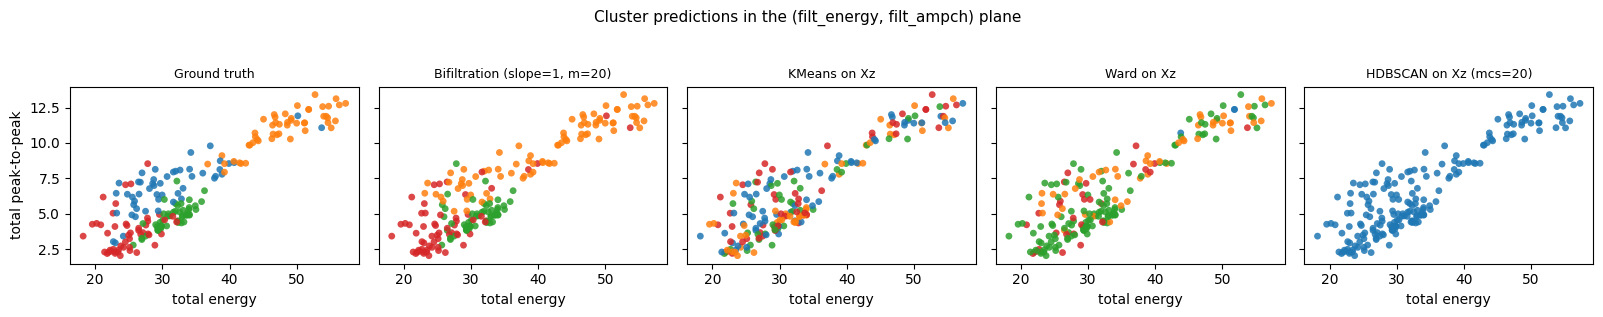

In [11]:
PRED_COLORS = ['C0', 'C1', 'C2', 'C3']

total_energy = energy_pc.sum(axis=1)
total_ampch  = ampch.sum(axis=1)

methods_to_show = [("Ground truth", y_true)] + [(name, labels) for name, labels in methods.items()]

fig, axes = plt.subplots(1, len(methods_to_show), figsize=(16, 3.0),
                         sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, methods_to_show):
    labels = np.asarray(labels)
    if name == "Ground truth":
        color_idx = labels
    else:
        a, _ = align_hungarian(labels, y_true)
        color_idx = (a - 1) % K_TRUE
    colors = [PRED_COLORS[c] for c in color_idx]
    ax.scatter(total_energy, total_ampch, c=colors, s=24, alpha=0.85, edgecolors='none')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('total energy')
axes[0].set_ylabel('total peak-to-peak')
fig.suptitle('Cluster predictions in the (filt_energy, filt_ampch) plane', y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

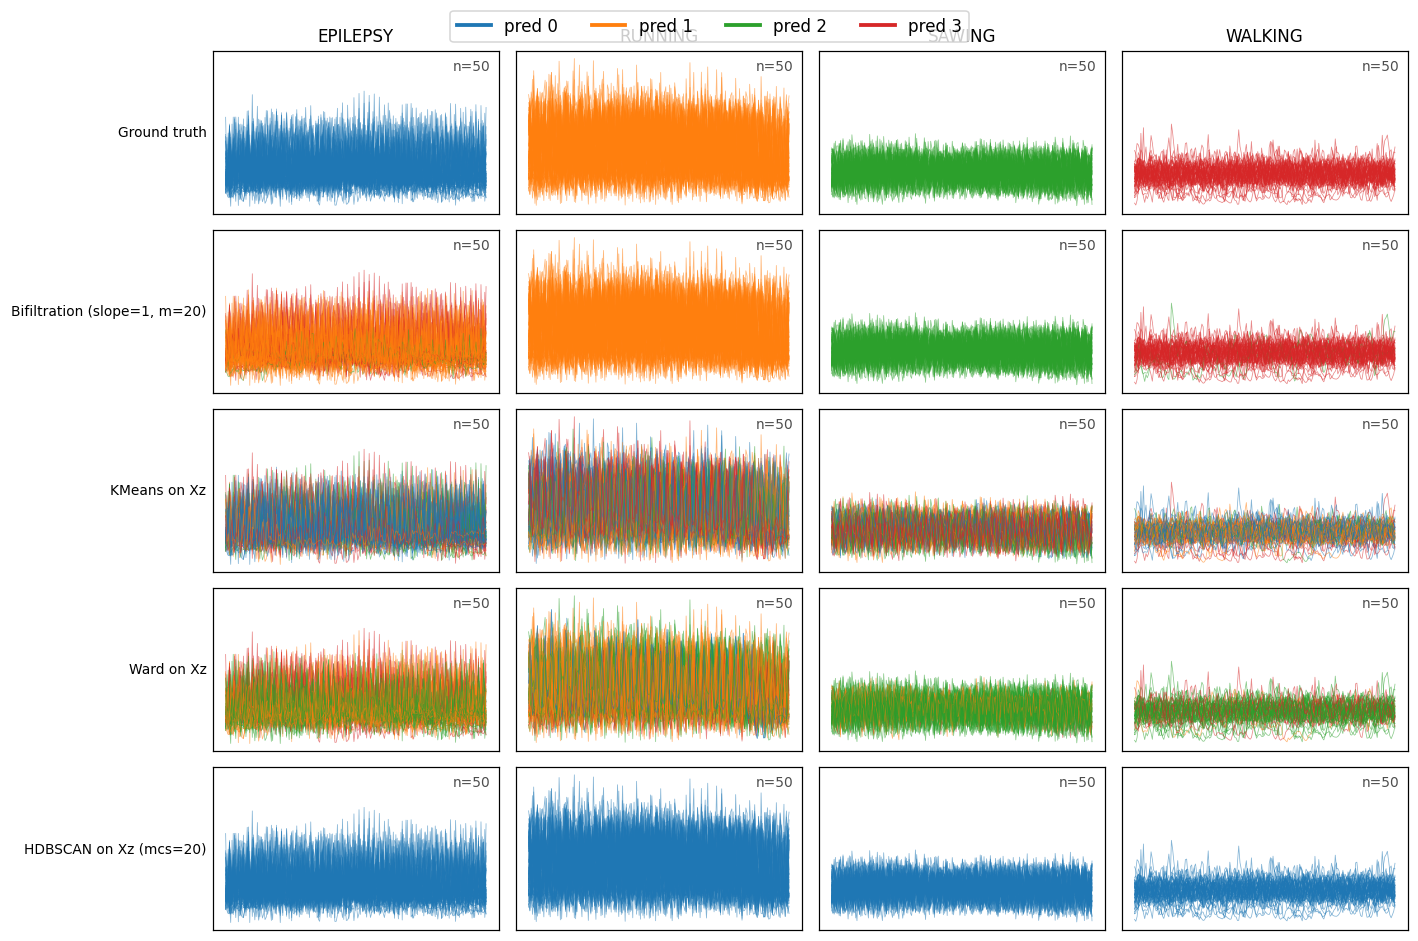

In [12]:
X_mag = np.linalg.norm(X, axis=2)

rows_to_show = [("Ground truth", y_true)] + [(name, labels) for name, labels in methods.items()]

fig, axes = plt.subplots(len(rows_to_show), K_TRUE,
                         figsize=(13, 1.7 * len(rows_to_show)),
                         sharex=True, sharey=True, dpi=110)
for row, (name, labels) in enumerate(rows_to_show):
    labels = np.asarray(labels)
    if name == "Ground truth":
        color_idx = labels
    else:
        a, _ = align_hungarian(labels, y_true)
        color_idx = (a - 1) % K_TRUE
    for col in range(K_TRUE):
        ax = axes[row, col]
        idxs = np.where(y_true == col)[0]
        for i in idxs:
            ax.plot(X_mag[i], color=PRED_COLORS[color_idx[i]], lw=0.5, alpha=0.55)
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.97, 0.95, f'n={len(idxs)}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='0.3')
        if row == 0:
            ax.set_title(f'{CLASSES[col]}', fontsize=11)
        if col == 0:
            ax.set_ylabel(name, fontsize=9, rotation=0, ha='right', va='center')

handles = [plt.Line2D([0], [0], color=PRED_COLORS[c], lw=2.5, label=f'pred {c}')
           for c in range(K_TRUE)]
fig.legend(handles=handles, loc='upper center', ncol=K_TRUE,
           bbox_to_anchor=(0.5, 1.01), fontsize=11)
fig.tight_layout()
plt.show()